# Final Project Sains Data - Prediksi Harga Mobil

**Nama:** Ghufron Faishal Ihsan  
**NPM:** 237006114  
**Matakuliah:** Sains Data  
**Project:** CarPrice Prediction  
**Metode:** CRISP-DM  
**Model:** Linear Regression  
**Dataset:** `Car_sales.xls`  
**Target Prediksi:** Harga mobil dalam ribuan USD
**Dataset:** `Car_sales.xls`

# CRISP-DM Checklist — CarPrice Prediction

Dokumen ini menjelaskan posisi project terhadap ketentuan final project Sains Data.

## 1. Business Understanding
- Studi kasus: perusahaan manufaktur otomotif membutuhkan sistem untuk merekomendasikan spesifikasi mobil dan memprediksi harga mobil.
- Tujuan: membantu estimasi harga berdasarkan fitur teknis kendaraan.

## 2. Data Understanding
- Dataset: `Car_sales.xls`.
- Target prediksi: `Price_in_thousands`.
- Fitur input utama: `Engine_size`, `Horsepower`, `Wheelbase`, `Width`, `Length`, `Curb_weight`, `Fuel_capacity`, `Fuel_efficiency`, dan `Vehicle_type`.

## 3. Data Preparation
- Menghapus duplikasi data.
- Menghapus baris yang target harga-nya kosong.
- Mengisi missing value numerik menggunakan median.
- Mengisi missing value kategorikal menggunakan modus/most frequent.
- Melakukan One-Hot Encoding untuk `Vehicle_type`.
- Melakukan StandardScaler untuk fitur numerik.

## 4. Modeling
- Algoritma: Linear Regression.
- Split data: 80% training dan 20% testing.
- Pipeline: preprocessing + model regresi.

## 5. Evaluation
- R² Score: `0.7877`.
- RMSE: `6.7549` ribu USD.
- Scatter plot evaluasi tersedia di `assets/evaluation_scatter_plot.png`.

## 6. Deployment
- Backend: FastAPI.
- Frontend: HTML, CSS, JavaScript.
- Rekomendasi hosting gratis: Render untuk backend dan Vercel untuk frontend.

## File terkait
- Notebook Google Colab: `notebooks/CarPrice_Prediction_CRISPDM_LinearRegression.ipynb`.
- Dataset Colab: `notebooks/Car_sales.xls`.
- Script training web: `backend/train_model.py`.
- Model hasil training: `backend/car_price_model.joblib`.


## Business Understanding — CRISP-DM

Perusahaan manufaktur otomotif membutuhkan sistem berbasis data untuk membantu proses perencanaan produk. Masalah utama yang ingin diselesaikan adalah:

1. **Merekomendasikan spesifikasi mobil** yang sesuai dengan preferensi pasar berdasarkan data penjualan historis.
2. **Memprediksi harga mobil** berdasarkan spesifikasi teknis yang dirancang atau diinputkan oleh pengguna.
3. Menyediakan rancangan model yang dapat digunakan pada **aplikasi web** agar end user dapat melakukan prediksi melalui browser.

### Tujuan

- Mengidentifikasi 10 model mobil dengan penjualan tertinggi.
- Menganalisis karakteristik harga dan spesifikasi dari model-model terlaris.
- Membangun model regresi linear untuk memprediksi harga mobil.
- Mengevaluasi performa model secara kuantitatif menggunakan RMSE dan R² Score.


## 1. Memanggil Library yang Diperlukan

In [1]:
import os
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

try:
    import xlrd
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlrd"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


## 2. Load Data


In [2]:
DATA_PATH = "Car_sales.xls"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Silakan upload file Car_sales.xls")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except Exception as error:
        raise FileNotFoundError(
            "File Car_sales.xls tidak ditemukan. Upload file tersebut ke Colab terlebih dahulu."
        ) from error

def load_car_sales(path):
    """Membaca file Excel secara fleksibel untuk .xls/.xlsx di Colab."""
    readers = [
        {"engine": None, "label": "auto"},
        {"engine": "openpyxl", "label": "openpyxl"},
        {"engine": "xlrd", "label": "xlrd"},
    ]
    errors = []
    for reader in readers:
        try:
            if reader["engine"] is None:
                data = pd.read_excel(path)
            else:
                data = pd.read_excel(path, engine=reader["engine"])
            print(f"Berhasil membaca data menggunakan engine: {reader['label']}")
            return data
        except Exception as error:
            errors.append(f"{reader['label']}: {error}")
    raise ValueError("Gagal membaca file Excel. Detail error: " + " | ".join(errors))

df_raw = load_car_sales(DATA_PATH)

print("Shape dataset:", df_raw.shape)
display(df_raw.head())

Berhasil membaca data menggunakan engine: auto
Shape dataset: (157, 16)


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2012-02-02 00:00:00,58.280
1,Acura,TL,39.384,19.875,Passenger,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,2011-03-06 00:00:00,91.371
2,Acura,CL,14.114,18.225,Passenger,NaN,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2012-04-01 00:00:00,NaN
3,Acura,RL,8.588,29.725,Passenger,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2011-10-03 00:00:00,91.390
4,Audi,A4,20.397,22.255,Passenger,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,2011-08-10 00:00:00,62.778


## 3. Melihat Data — Data Understanding

In [3]:
print("Informasi dataset:")
df_raw.info()

print("\nJumlah data duplikat:", df_raw.duplicated().sum())

print("\nStatistik deskriptif:")
display(df_raw.describe(include="all").T)

missing_before = pd.DataFrame({
    "Missing Count": df_raw.isna().sum(),
    "Missing Percent (%)": (df_raw.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

print("\nKolom dengan missing value:")
display(missing_before[missing_before["Missing Count"] > 0])


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Manufacturer,157,30,Ford,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,157,156,Neon,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_in_thousands,157.000,NaN,NaN,NaN,52.998,68.029,0.110,14.114,29.450,67.956,540.561
__year_resale_value,121.000,NaN,NaN,NaN,18.073,11.453,5.160,11.260,14.180,19.875,67.550
Vehicle_type,157,2,Passenger,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price_in_thousands,155.000,NaN,NaN,NaN,27.391,14.352,9.235,18.017,22.799,31.947,85.500
Engine_size,156.000,NaN,NaN,NaN,3.061,1.045,1.000,2.300,3.000,3.575,8.000
Horsepower,156.000,NaN,NaN,NaN,185.949,56.700,55.000,149.500,177.500,215.000,450.000
Wheelbase,156.000,NaN,NaN,NaN,107.487,7.641,92.600,103.000,107.000,112.200,138.700
Width,156.000,NaN,NaN,NaN,71.150,3.452,62.600,68.400,70.550,73.425,79.900



Kolom dengan missing value:


,Missing Count,Missing Percent (%)
__year_resale_value,36,22.930
Fuel_efficiency,3,1.910
Curb_weight,2,1.270
Price_in_thousands,2,1.270
Power_perf_factor,2,1.270
Wheelbase,1,0.640
Engine_size,1,0.640
Horsepower,1,0.640
Length,1,0.640
Width,1,0.640


## 4. Menghapus Missing Value

In [4]:
target = "Price_in_thousands"

df_work = df_raw.copy()

print("Jumlah data awal:", len(df_work))
print("Jumlah duplikat:", df_work.duplicated().sum())
print("Missing target Price_in_thousands:", df_work[target].isna().sum())

df_work = df_work.drop_duplicates()
df_work = df_work.dropna(subset=[target])

print("Jumlah data setelah drop duplicate dan missing target:", len(df_work))


Jumlah data awal: 157
Jumlah duplikat: 0
Missing target Price_in_thousands: 2
Jumlah data setelah drop duplicate dan missing target: 155


## 5. Mengisi Missing Value

In [5]:
numeric_features = [
    "Engine_size", "Horsepower", "Wheelbase", "Width", "Length",
    "Curb_weight", "Fuel_capacity", "Fuel_efficiency"
]

categorical_features = ["Vehicle_type"]

print("Missing pada fitur sebelum imputasi:")
display(df_work[numeric_features + categorical_features].isna().sum().to_frame("Missing Count"))

df_clean = df_work.copy()

for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing setelah imputasi pada data EDA/rekomendasi:")
display(df_clean[numeric_features + categorical_features + [target]].isna().sum().to_frame("Missing Count"))


Missing pada fitur sebelum imputasi:


,Missing Count
Engine_size,0
Horsepower,0
Wheelbase,0
Width,0
Length,0
Curb_weight,1
Fuel_capacity,0
Fuel_efficiency,2
Vehicle_type,0


Missing setelah imputasi pada data EDA/rekomendasi:


,Missing Count
Engine_size,0
Horsepower,0
Wheelbase,0
Width,0
Length,0
Curb_weight,0
Fuel_capacity,0
Fuel_efficiency,0
Vehicle_type,0
Price_in_thousands,0


## 6. Eksplorasi Data

Eksplorasi difokuskan pada **10 jenis mobil dengan jumlah penjualan terbanyak** karena bagian ini menjadi dasar rekomendasi spesifikasi produk yang diminati pasar.


### 6a. Chart dan Penjelasan 10 Jenis Mobil dengan Jumlah Penjualan Terbanyak

,Manufacturer,Model,Vehicle_type,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_efficiency
0,Ford,F-Series,Car,540.561,26.935,4.600,220.000,18.000
1,Ford,Explorer,Car,276.747,31.930,4.000,210.000,19.000
2,Toyota,Camry,Passenger,247.994,17.518,2.200,133.000,27.000
3,Ford,Taurus,Passenger,245.815,17.885,3.000,155.000,24.000
4,Honda,Accord,Passenger,230.902,15.350,2.300,135.000,27.000
5,Dodge,Ram Pickup,Car,227.061,19.460,5.200,230.000,17.000
6,Ford,Ranger,Car,220.650,12.050,2.500,119.000,23.000
7,Honda,Civic,Passenger,199.685,12.885,1.600,106.000,32.000
8,Dodge,Caravan,Car,181.749,19.565,2.400,150.000,24.000
9,Ford,Focus,Passenger,175.670,12.315,2.000,107.000,30.000


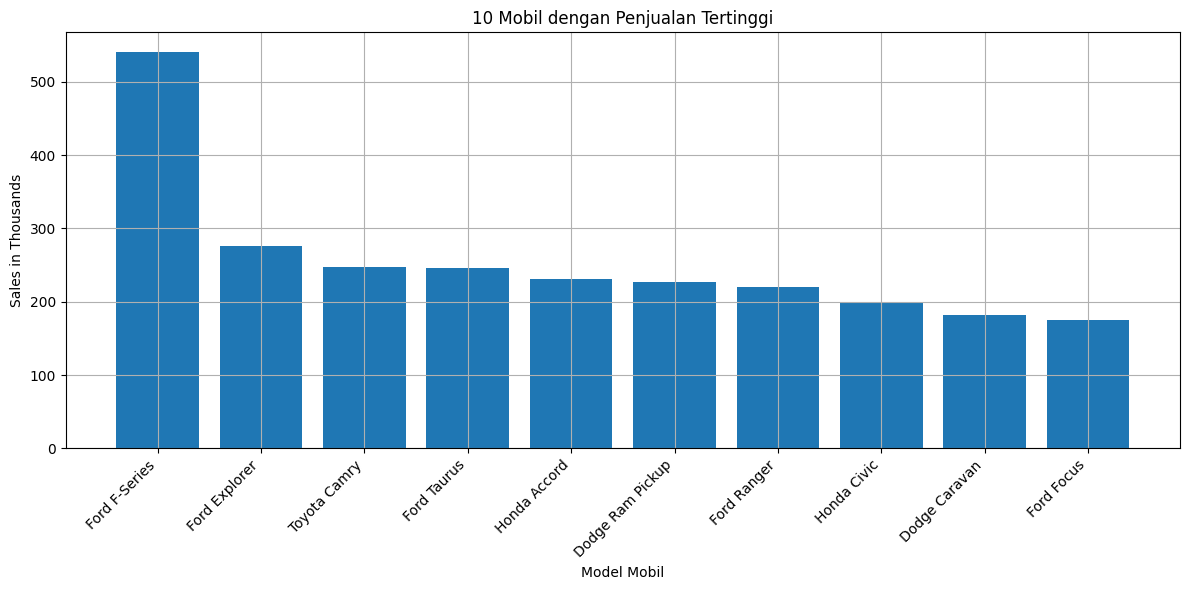

Analisis: Model dengan penjualan tertinggi adalah Ford F-Series dengan penjualan 540.561 ribu unit. Dominasi beberapa model mass-market menunjukkan bahwa pasar lebih responsif terhadap kendaraan yang fungsional, harga relatif terjangkau, dan sesuai kebutuhan keluarga/utility.


In [6]:
top10 = df_clean.sort_values("Sales_in_thousands", ascending=False).head(10).copy()
top10["Label"] = top10["Manufacturer"] + " " + top10["Model"]

top10_display = top10[[
    "Manufacturer", "Model", "Vehicle_type", "Sales_in_thousands", target,
    "Engine_size", "Horsepower", "Fuel_efficiency"
]].reset_index(drop=True)

display(top10_display)

plt.figure(figsize=(12, 6))
plt.bar(top10["Label"], top10["Sales_in_thousands"])
plt.xticks(rotation=45, ha="right")
plt.title("10 Mobil dengan Penjualan Tertinggi")
plt.xlabel("Model Mobil")
plt.ylabel("Sales in Thousands")
plt.tight_layout()
plt.show()

best_seller = top10.iloc[0]
print(
    f"Analisis: Model dengan penjualan tertinggi adalah {best_seller['Manufacturer']} {best_seller['Model']} "
    f"dengan penjualan {best_seller['Sales_in_thousands']:.3f} ribu unit. "
    "Dominasi beberapa model mass-market menunjukkan bahwa pasar lebih responsif terhadap kendaraan yang fungsional, "
    "harga relatif terjangkau, dan sesuai kebutuhan keluarga/utility."
)


### 6b. Menampilkan Harga dan Penjelasan dari 10 Jenis Mobil dengan Jumlah Penjualan Terbanyak

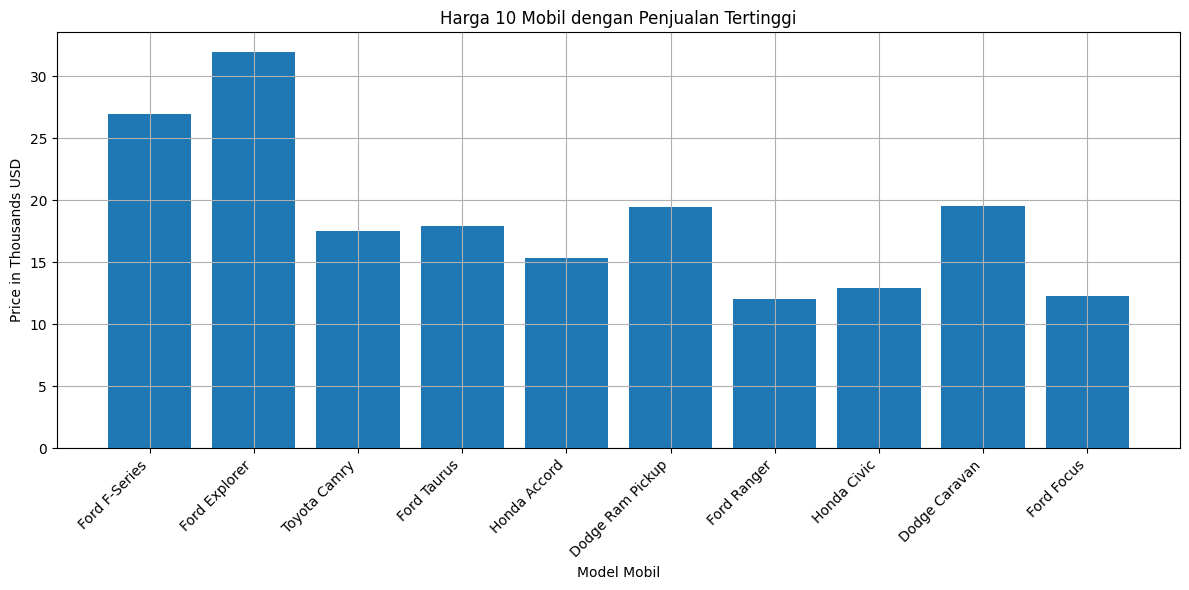

Rata-rata harga top 10 mobil terlaris: 18.59 ribu USD
Rentang harga top 10 mobil terlaris: 12.05 - 31.93 ribu USD
Analisis: Mobil terlaris berada pada rentang harga yang relatif terjangkau untuk pasar volume tinggi. Hal ini memberi sinyal bahwa spesifikasi rekomendasi sebaiknya tidak hanya mengejar performa tinggi, tetapi juga menjaga harga pada segmen mass-market.


In [7]:
plt.figure(figsize=(12, 6))
plt.bar(top10["Label"], top10[target])
plt.xticks(rotation=45, ha="right")
plt.title("Harga 10 Mobil dengan Penjualan Tertinggi")
plt.xlabel("Model Mobil")
plt.ylabel("Price in Thousands USD")
plt.tight_layout()
plt.show()

avg_price_top10 = top10[target].mean()
min_price_top10 = top10[target].min()
max_price_top10 = top10[target].max()

print(f"Rata-rata harga top 10 mobil terlaris: {avg_price_top10:.2f} ribu USD")
print(f"Rentang harga top 10 mobil terlaris: {min_price_top10:.2f} - {max_price_top10:.2f} ribu USD")
print(
    "Analisis: Mobil terlaris berada pada rentang harga yang relatif terjangkau untuk pasar volume tinggi. "
    "Hal ini memberi sinyal bahwa spesifikasi rekomendasi sebaiknya tidak hanya mengejar performa tinggi, "
    "tetapi juga menjaga harga pada segmen mass-market."
)


### 6c. Minimal 3 Variabel/Atribut Lain dari 10 Jenis Mobil dengan Jumlah Penjualan Terbanyak

Atribut yang dianalisis: `Horsepower`, `Fuel_efficiency`, `Engine_size`, dan `Curb_weight`.


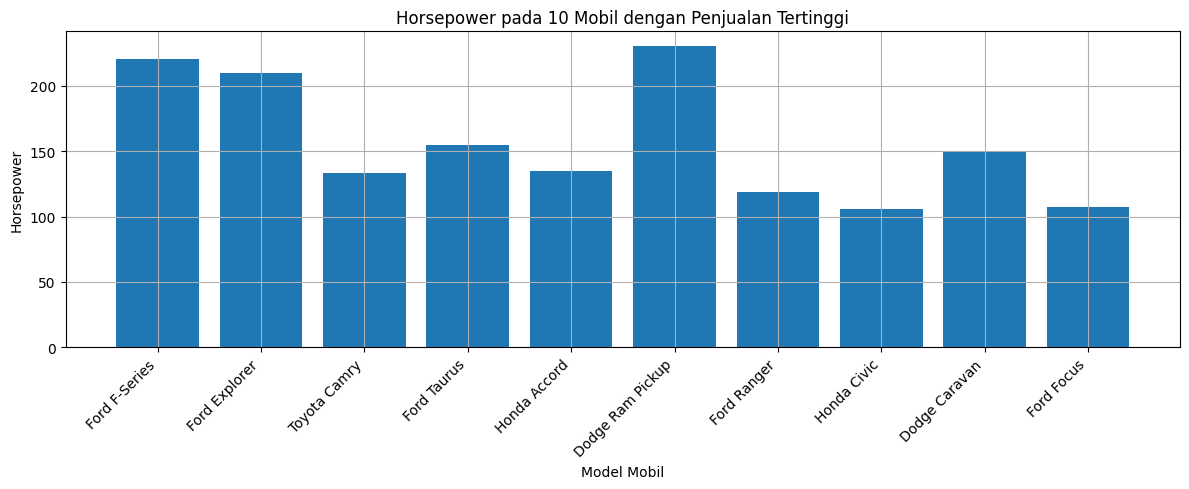

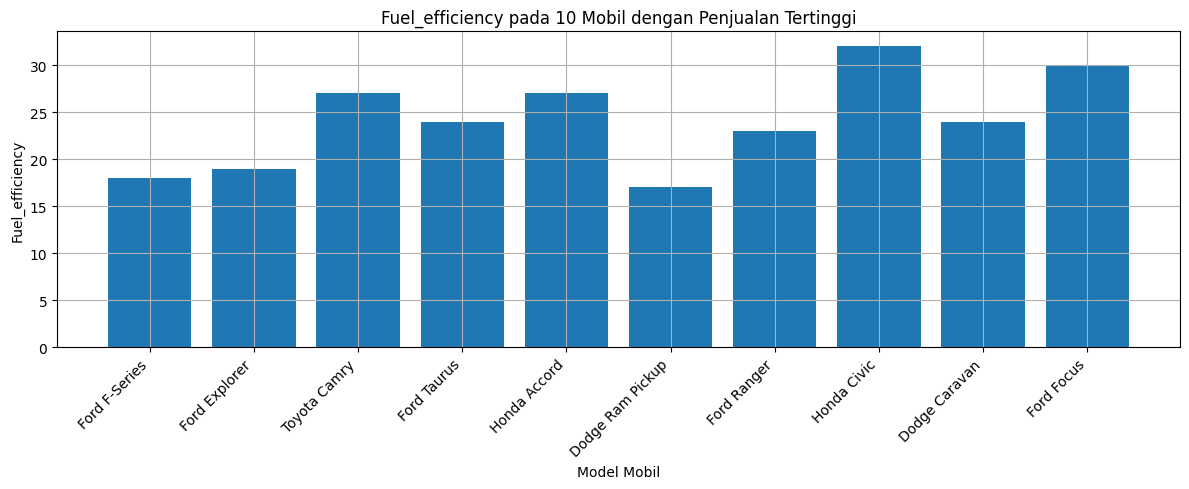

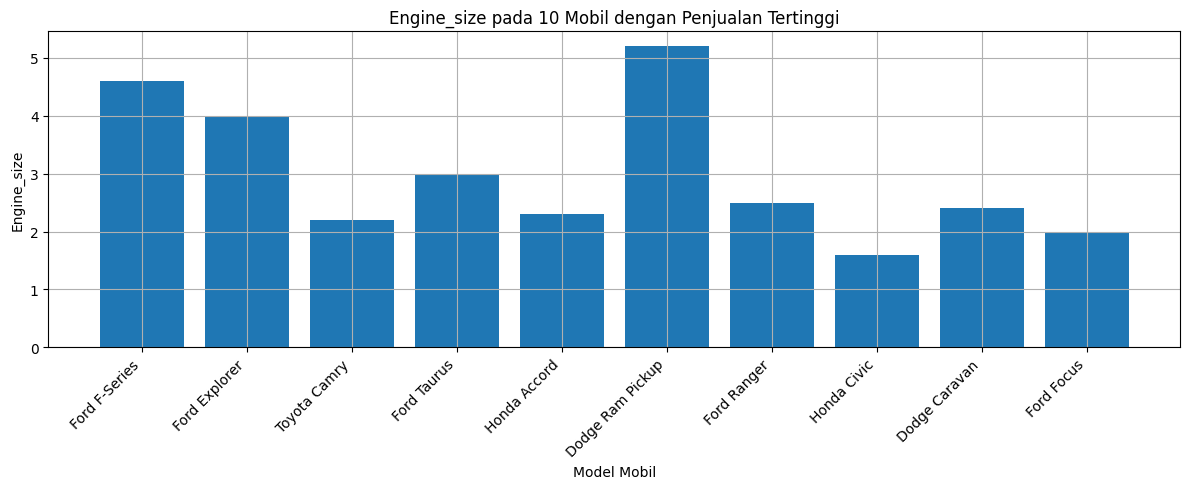

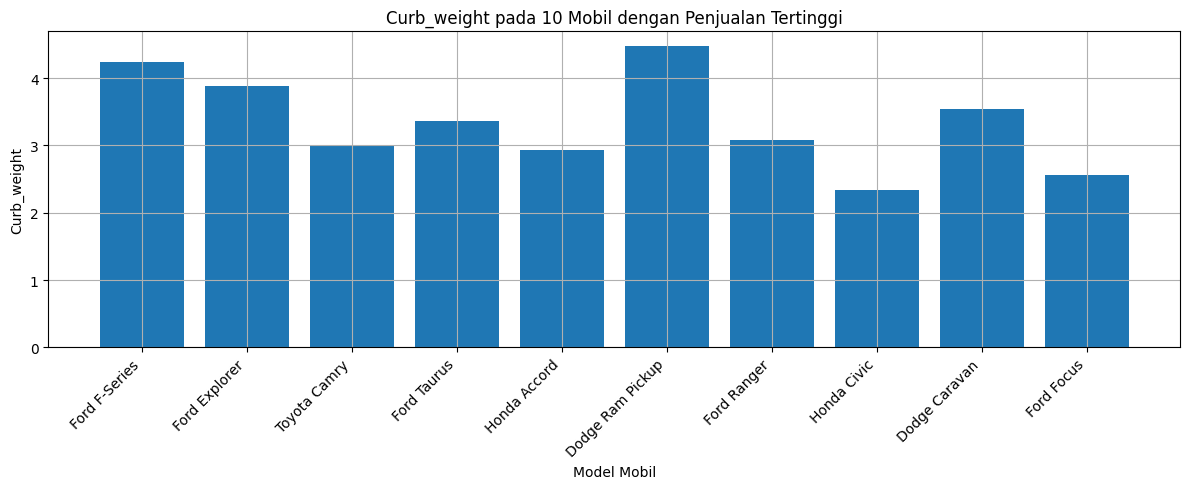

Rata-rata spesifikasi top 10 mobil terlaris:


,Rata-rata Top 10
Engine_size,2.980
Horsepower,156.500
Wheelbase,114.640
Width,72.220
Length,195.120
Curb_weight,3.340
Fuel_capacity,18.880
Fuel_efficiency,24.100
Price_in_thousands,18.590


Analisis: Top 10 penjualan menunjukkan kombinasi spesifikasi yang seimbang: engine size dan horsepower tidak ekstrem, fuel efficiency masih cukup baik, dan curb weight menunjukkan kombinasi sedan, minivan, serta truck/SUV. Spesifikasi seperti ini lebih realistis untuk produk yang mengejar volume penjualan.


In [8]:
eda_vars = ["Horsepower", "Fuel_efficiency", "Engine_size", "Curb_weight"]

for col in eda_vars:
    plt.figure(figsize=(12, 5))
    plt.bar(top10["Label"], top10[col])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{col} pada 10 Mobil dengan Penjualan Tertinggi")
    plt.xlabel("Model Mobil")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

print("Rata-rata spesifikasi top 10 mobil terlaris:")
display(top10[numeric_features + [target]].mean().to_frame("Rata-rata Top 10").round(2))

print(
    "Analisis: Top 10 penjualan menunjukkan kombinasi spesifikasi yang seimbang: engine size dan horsepower tidak ekstrem, "
    "fuel efficiency masih cukup baik, dan curb weight menunjukkan kombinasi sedan, minivan, serta truck/SUV. "
    "Spesifikasi seperti ini lebih realistis untuk produk yang mengejar volume penjualan."
)


## 7. Menentukan Variabel untuk Rekomendasi Spesifikasi Mobil

In [9]:
numeric_candidate_cols = [
    "Sales_in_thousands", "__year_resale_value", "Engine_size", "Horsepower",
    "Wheelbase", "Width", "Length", "Curb_weight", "Fuel_capacity",
    "Fuel_efficiency", "Power_perf_factor", target
]

available_numeric_candidates = [col for col in numeric_candidate_cols if col in df_clean.columns]
corr_to_price = (
    df_clean[available_numeric_candidates]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("Correlation with Price")
)

display(corr_to_price)

feature_decision = pd.DataFrame([
    ["Engine_size", "Dipakai", "Spesifikasi fisik mesin dan relevan untuk input user."],
    ["Horsepower", "Dipakai", "Menggambarkan performa kendaraan."],
    ["Wheelbase", "Dipakai", "Mewakili dimensi dan kelas kendaraan."],
    ["Width", "Dipakai", "Mewakili ukuran bodi kendaraan."],
    ["Length", "Dipakai", "Mewakili ukuran bodi dan segmen kendaraan."],
    ["Curb_weight", "Dipakai", "Mewakili bobot/konstruksi kendaraan."],
    ["Fuel_capacity", "Dipakai", "Membantu membedakan city car, sedan, SUV, dan truck."],
    ["Fuel_efficiency", "Dipakai", "Konsumsi BBM adalah faktor pasar yang penting."],
    ["Vehicle_type", "Dipakai", "Kategori kendaraan perlu dibedakan dengan one-hot encoding."],
    ["Sales_in_thousands", "Tidak dipakai", "Penjualan adalah outcome pasar, bukan spesifikasi yang diketahui saat desain mobil baru."],
    ["Manufacturer", "Tidak dipakai", "Nama brand bukan spesifikasi teknis dan bisa membuat model terlalu bergantung pada identitas merek."],
    ["Model", "Tidak dipakai", "Nama model adalah identifier, bukan input spesifikasi produksi baru."],
    ["Latest_Launch", "Tidak dipakai", "Tanggal launch tidak diminta sebagai input end user."],
    ["__year_resale_value", "Tidak dipakai", "Nilai resale tidak selalu tersedia untuk mobil baru dan memiliki banyak missing value."],
    ["Power_perf_factor", "Tidak dipakai", "Sangat berkaitan dengan performa/harga dan dapat membuat model terlalu bergantung pada fitur turunan."],
], columns=["Variabel", "Keputusan", "Alasan"])

display(feature_decision)

recommended_specs = top10[numeric_features].mean().round(2)
recommended_type = top10["Vehicle_type"].mode()[0]

print("Rekomendasi spesifikasi awal berdasarkan rata-rata 10 mobil terlaris:")
display(recommended_specs.to_frame("Recommended Value"))
print("Rekomendasi Vehicle_type:", recommended_type)


,Correlation with Price
__year_resale_value,0.954
Power_perf_factor,0.898
Horsepower,0.840
Engine_size,0.627
Curb_weight,0.523
Fuel_efficiency,-0.492
Fuel_capacity,0.423
Width,0.329
Sales_in_thousands,-0.305
Length,0.157


,Variabel,Keputusan,Alasan
0,Engine_size,Dipakai,Spesifikasi fisik mesin dan relevan untuk inpu...
1,Horsepower,Dipakai,Menggambarkan performa kendaraan.
2,Wheelbase,Dipakai,Mewakili dimensi dan kelas kendaraan.
3,Width,Dipakai,Mewakili ukuran bodi kendaraan.
4,Length,Dipakai,Mewakili ukuran bodi dan segmen kendaraan.
5,Curb_weight,Dipakai,Mewakili bobot/konstruksi kendaraan.
6,Fuel_capacity,Dipakai,"Membantu membedakan city car, sedan, SUV, dan ..."
7,Fuel_efficiency,Dipakai,Konsumsi BBM adalah faktor pasar yang penting.
8,Vehicle_type,Dipakai,Kategori kendaraan perlu dibedakan dengan one-...
9,Sales_in_thousands,Tidak dipakai,"Penjualan adalah outcome pasar, bukan spesifik..."


Rekomendasi spesifikasi awal berdasarkan rata-rata 10 mobil terlaris:


,Recommended Value
Engine_size,2.980
Horsepower,156.500
Wheelbase,114.640
Width,72.220
Length,195.120
Curb_weight,3.340
Fuel_capacity,18.880
Fuel_efficiency,24.100


Rekomendasi Vehicle_type: Car


## 8. Membuat Model Prediksi Harga Mobil Menggunakan LinearRegression

### 8a. Memisahkan Variabel Independent dan Dependent

In [10]:
selected_features = numeric_features + categorical_features

X = df_work[selected_features]
y = df_work[target]

print("Independent variables:", list(X.columns))
print("Dependent variable:", target)
print("Jumlah data modeling:", len(X))


Independent variables: ['Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Vehicle_type']
Dependent variable: Price_in_thousands
Jumlah data modeling: 155


### 8b. Memisahkan Data Training 80% dan Data Testing 20%

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))
print(f"Proporsi training: {len(X_train) / len(X) * 100:.1f}%")
print(f"Proporsi testing : {len(X_test) / len(X) * 100:.1f}%")


Jumlah data training: 124
Jumlah data testing: 31
Proporsi training: 80.0%
Proporsi testing : 20.0%


### 8c. Membuat Model Regresi

In [12]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
print("Model LinearRegression berhasil dilatih.")


Model LinearRegression berhasil dilatih.


### 8d. Mengevaluasi Model dengan RMSE dan R² Score

In [13]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2 Score"],
    "Value": [rmse, mae, r2],
    "Interpretasi": [
        "Rata-rata error kuadrat dalam satuan ribu USD; semakin kecil semakin baik.",
        "Rata-rata selisih absolut prediksi terhadap harga aktual; semakin kecil semakin baik.",
        "Proporsi variasi harga yang dapat dijelaskan model; semakin mendekati 1 semakin baik."
    ]
})

display(metrics_df)

print(f"RMSE    : {rmse:.4f} ribu USD")
print(f"MAE     : {mae:.4f} ribu USD")
print(f"R2 Score: {r2:.4f}")

if r2 >= 0.80:
    quality = "baik"
elif r2 >= 0.60:
    quality = "cukup baik/moderat"
else:
    quality = "perlu ditingkatkan"

print(f"Interpretasi: Dengan R2 {r2:.4f}, model termasuk kategori {quality} untuk baseline Linear Regression pada dataset kecil.")


,Metric,Value,Interpretasi
0,RMSE,6.755,Rata-rata error kuadrat dalam satuan ribu USD;...
1,MAE,4.285,Rata-rata selisih absolut prediksi terhadap ha...
2,R2 Score,0.788,Proporsi variasi harga yang dapat dijelaskan m...


RMSE    : 6.7549 ribu USD
MAE     : 4.2846 ribu USD
R2 Score: 0.7877
Interpretasi: Dengan R2 0.7877, model termasuk kategori cukup baik/moderat untuk baseline Linear Regression pada dataset kecil.


### Validasi Tambahan: Cross Validation


In [14]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

cv_result = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(cv_scores))],
    "R2 Score": cv_scores
})

display(cv_result)
print(f"Rata-rata R2 Cross Validation: {cv_scores.mean():.4f}")
print(f"Standar deviasi R2 Cross Validation: {cv_scores.std():.4f}")


,Fold,R2 Score
0,Fold 1,0.818
1,Fold 2,0.609
2,Fold 3,0.684
3,Fold 4,0.732
4,Fold 5,0.794


Rata-rata R2 Cross Validation: 0.7273
Standar deviasi R2 Cross Validation: 0.0757


### 8e. Menggambarkan Hasil Evaluasi dengan Scatter Plot

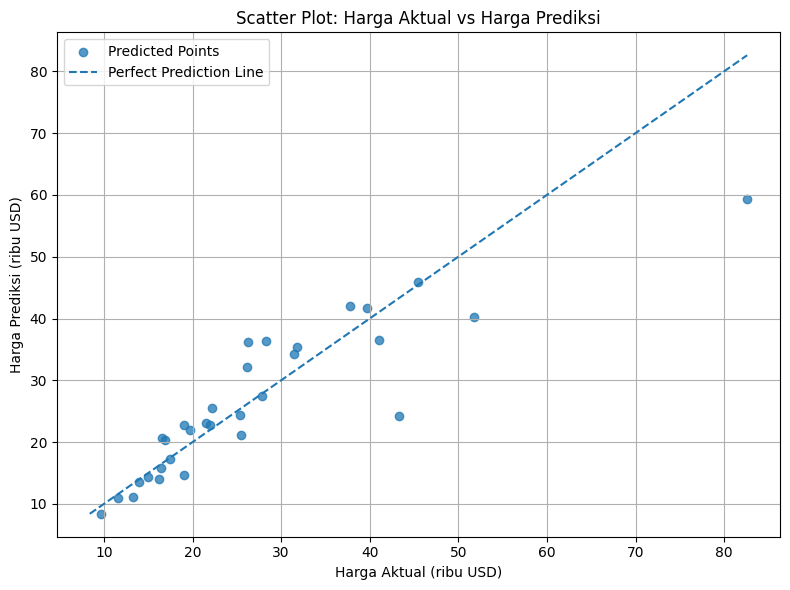

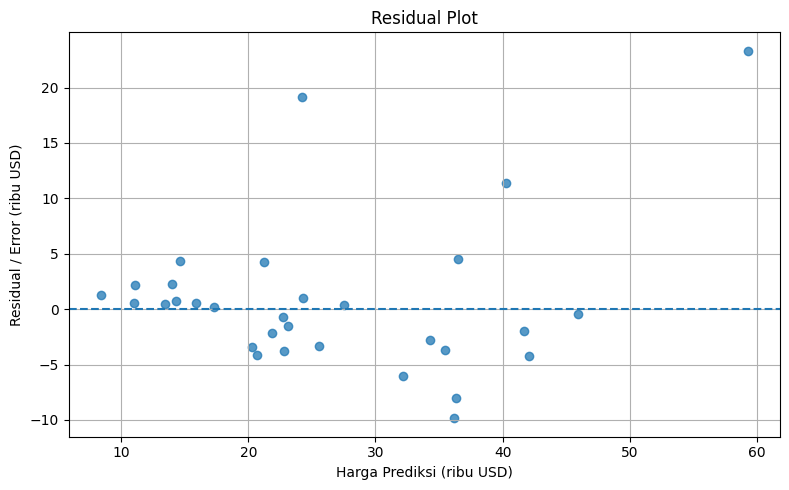

Analisis: Titik yang dekat dengan garis diagonal menunjukkan prediksi yang baik. Residual yang menyebar di sekitar nol menunjukkan error relatif seimbang.


In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.75, label="Predicted Points")
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect Prediction Line")
plt.xlabel("Harga Aktual (ribu USD)")
plt.ylabel("Harga Prediksi (ribu USD)")
plt.title("Scatter Plot: Harga Aktual vs Harga Prediksi")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Harga Prediksi (ribu USD)")
plt.ylabel("Residual / Error (ribu USD)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

print("Analisis: Titik yang dekat dengan garis diagonal menunjukkan prediksi yang baik. Residual yang menyebar di sekitar nol menunjukkan error relatif seimbang.")


## 9. Memprediksi Harga dengan Spesifikasi Mobil yang Telah Ditentukan Menggunakan DataFrame

In [16]:
# Contoh input spesifikasi mobil baru berdasarkan segmen pasar mass-market.
new_car = pd.DataFrame([
    {
        "Engine_size": 2.3,
        "Horsepower": 150,
        "Wheelbase": 107,
        "Width": 70,
        "Length": 185,
        "Curb_weight": 3.1,
        "Fuel_capacity": 16,
        "Fuel_efficiency": 27,
        "Vehicle_type": "Passenger"
    }
])

print("DataFrame input prediksi:")
display(new_car)


DataFrame input prediksi:


,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Vehicle_type
0,2.300,150,107,70,185,3.100,16,27,Passenger


## 10. Menampilkan Hasil Prediksi Harga

In [17]:
predicted_price = model.predict(new_car)[0]
predicted_price = max(0, predicted_price)
prediction_result = pd.DataFrame({
    "Prediksi Harga (ribu USD)": [predicted_price],
    "Prediksi Harga (USD)": [predicted_price * 1000],
    "Estimasi Rentang Bawah (USD)": [(predicted_price - rmse) * 1000],
    "Estimasi Rentang Atas (USD)": [(predicted_price + rmse) * 1000]
})

display(prediction_result)

print(f"Prediksi harga mobil: {predicted_price:.2f} ribu USD")
print(f"Prediksi harga mobil: ${predicted_price * 1000:,.0f}")
print(f"Rentang estimasi berbasis RMSE: ${(predicted_price - rmse) * 1000:,.0f} - ${(predicted_price + rmse) * 1000:,.0f}")


,Prediksi Harga (ribu USD),Prediksi Harga (USD),Estimasi Rentang Bawah (USD),Estimasi Rentang Atas (USD)
0,21.575,"21,575.420","14,820.523","28,330.316"


Prediksi harga mobil: 21.58 ribu USD
Prediksi harga mobil: $21,575
Rentang estimasi berbasis RMSE: $14,821 - $28,330


## 11. Deployment Model ke Halaman Web

Arsitektur:

```text
User Browser
   ↓
Frontend
   ↓
Backend FastAPI
   ↓
Model LinearRegression Pipeline (.joblib)
```


In [18]:
# Simpan model pipeline agar dapat digunakan pada backend/deployment.
MODEL_PATH = "car_price_model.joblib"
joblib.dump(model, MODEL_PATH)
print(f"Model berhasil disimpan ke: {MODEL_PATH}")

# Simpan daftar fitur agar backend/frontend memakai urutan kolom yang sama.
FEATURE_CONFIG = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": target,
    "rmse": float(rmse),
    "r2_score": float(r2)
}

with open("feature_config.json", "w", encoding="utf-8") as f:
    import json
    json.dump(FEATURE_CONFIG, f, indent=2)

print("Konfigurasi fitur berhasil disimpan ke: feature_config.json")


Model berhasil disimpan ke: car_price_model.joblib
Konfigurasi fitur berhasil disimpan ke: feature_config.json


In [19]:
def predict_car_price(
    engine_size=2.3,
    horsepower=150,
    wheelbase=107,
    width=70,
    length=185,
    curb_weight=3.1,
    fuel_capacity=16,
    fuel_efficiency=27,
    vehicle_type="Passenger"
):
    '''Fungsi prediksi yang dapat diadaptasi menjadi endpoint backend.'''
    input_df = pd.DataFrame([
        {
            "Engine_size": engine_size,
            "Horsepower": horsepower,
            "Wheelbase": wheelbase,
            "Width": width,
            "Length": length,
            "Curb_weight": curb_weight,
            "Fuel_capacity": fuel_capacity,
            "Fuel_efficiency": fuel_efficiency,
            "Vehicle_type": vehicle_type
        }
    ])
    pred = model.predict(input_df)[0]
    pred = max(0, pred)
    return {
        "predicted_price_thousand_usd": round(float(pred), 3),
        "predicted_price_usd": round(float(pred * 1000), 2),
        "estimated_lower_usd": round(float((pred - rmse) * 1000), 2),
        "estimated_upper_usd": round(float((pred + rmse) * 1000), 2),
        "r2_score": round(float(r2), 4),
        "rmse_thousand_usd": round(float(rmse), 4)
    }

predict_car_price()


{'predicted_price_thousand_usd': 21.575,
 'predicted_price_usd': 21575.42,
 'estimated_lower_usd': 14820.52,
 'estimated_upper_usd': 28330.32,
 'r2_score': 0.7877,
 'rmse_thousand_usd': 6.7549}